# The Keeling Curve

Is atmospheric CO2 still climbing, and is it climbing faster than it used to? This notebook plots the full Mauna Loa monthly CO2 record — the famous sawtooth-shaped **Keeling Curve** — since 1958, then compares how fast CO2 was rising per decade.

Data source: **NOAA Global Monitoring Laboratory**, a public CSV with no API key required.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

DATA_URL = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv"

df = pd.read_csv(DATA_URL, comment="#")
df = df[df["average"] > 0]  # drop missing-month placeholders
df.tail()

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
817,2026,4,2026.2917,431.12,428.61,23,1.16,0.46
818,2026,5,2026.3750,432.34,429.06,19,0.64,0.28
819,2026,6,2026.4583,431.43,428.99,19,0.27,0.12
820,2026,7,2026.5417,429.13,428.78,21,0.61,0.26
821,2026,8,2026.6250,427.55,429.51,17,0.36,0.17


## The curve

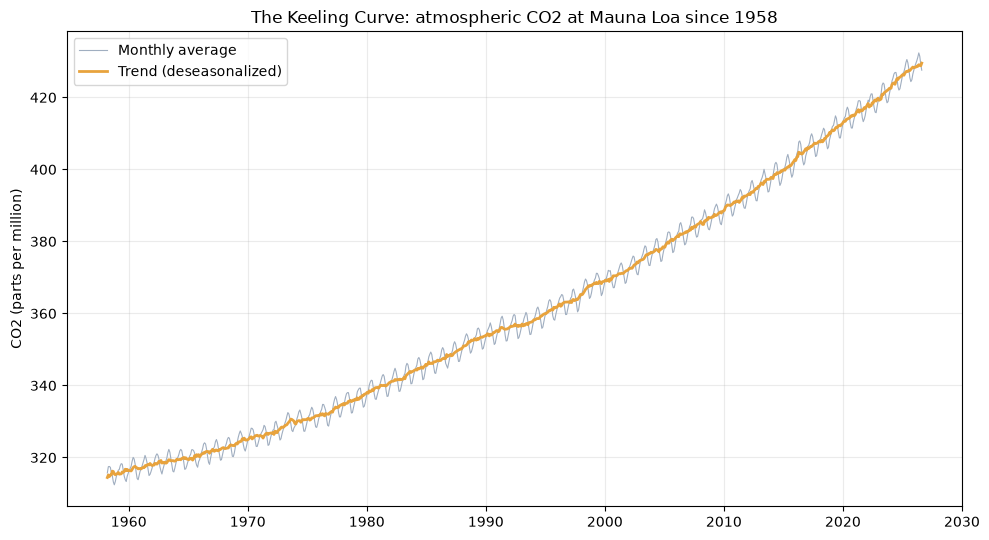

In [2]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(df["decimal date"], df["average"], color="#a0aec0", linewidth=0.8, label="Monthly average")
ax.plot(df["decimal date"], df["deseasonalized"], color="#e8a33d", linewidth=2, label="Trend (deseasonalized)")

ax.set_title("The Keeling Curve: atmospheric CO2 at Mauna Loa since 1958")
ax.set_ylabel("CO2 (parts per million)")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Is the rise accelerating?

In [3]:
df["decade"] = (df["year"] // 10) * 10
yearly = df.groupby("year")["average"].mean()
annual_increase = yearly.diff()
decade_avg_increase = annual_increase.groupby(yearly.index // 10 * 10).mean()

for decade, value in decade_avg_increase.items():
    if pd.notna(value):
        print(f"{int(decade)}s: {value:.2f} ppm/year")

1950s: 0.74 ppm/year
1960s: 0.86 ppm/year
1970s: 1.22 ppm/year
1980s: 1.64 ppm/year
1990s: 1.53 ppm/year
2000s: 1.91 ppm/year
2010s: 2.40 ppm/year
2020s: 2.62 ppm/year
